# HW4: Reinforcement Learning
# Part 1: Planar Drone
Ting-Wei Hsu (twhsu3)

In [1]:
import numpy as np
from qpsolvers import solve_problem, Problem
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Suppress the display of very small numbers
np.set_printoptions(suppress=True)


## Dynamical System

Consider a planar drone with the equations of motion
$$
\begin{aligned}
\dot{p}_x &= v_x \\
\dot{p}_z &= v_z \\
\dot{\theta} &= \omega \\
m\dot{v}_x &= -(T_1 + T_2)\sin\theta \\
m\dot{v}_z &= (T_1 + T_2)\cos\theta - mg \\
J_y \dot{\omega} &= r(T_1 - T_2)
\end{aligned}
$$

where $m = 0.45$ is the mass; 
$r = 0.14$ is the spar length;
$J_y = 0.09$ is the moment of inertia about the $y$ (out-of-plane) axis;
$g = 9.81$ is the acceleration of gravity;
$p_x$ and $p_z$ are the components of position;
$\theta$ is the orientation;
$v_x$ and $v_z$ are the components of linear velocity;
$\omega$ is the angular velocity;
$T_1$ and $T_2$ are the forces produced by each rotor.

We define the state and input as
$$
x = [p_x,\; p_z,\; \theta,\; v_x,\; v_z,\; \omega]^\top,
 \qquad
u = [T_1,\; T_2]^\top
$$
and the dynamicas as 
$$
\dot{x} = f(x,u)
$$

In [2]:
m = 0.45
r = 0.14
Jy = 0.09
grav = 9.81
dt = 0.04
N = 25
sim_time = 5.0

x_dim = 6
u_dim = 2

def dynamics(x, u):
    px, pz, theta, vx, vz, omega = x
    T1, T2 = u
    return np.array([
        vx,
        vz,
        omega,
        -(T1 + T2) / m * np.sin(theta),
        (T1 + T2) / m * np.cos(theta) - grav,
        r * (T1 - T2) / Jy,
    ])


def Jacobian_dynamics(x, u):
    _, _, theta, _, _, _ = x
    T1, T2 = u

    A = np.zeros((x_dim, x_dim))
    A[0, 3] = 1.0
    A[1, 4] = 1.0
    A[2, 5] = 1.0
    A[3, 2] = -(T1 + T2) / m * np.cos(theta)
    A[4, 2] = -(T1 + T2) / m * np.sin(theta)

    B = np.zeros((x_dim, u_dim))
    B[3, :] = -(1.0 / m) * np.sin(theta)
    B[4, :] =  (1.0 / m) * np.cos(theta)
    B[5, 0] =  r / Jy
    B[5, 1] = -r / Jy
    return A, B


In [3]:
x_start = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
x_goal  = np.array([3.0, 0.0, 0.0, 0.0, 0.0, 0.0])
u_ref = np.array([m * grav / 2.0, m * grav / 2.0])

## Gymnasium Environment

This environment keeps the planar quadrotor state from above. The observation augments that state with the relative goal and obstacle positions, while the action is the two bounded rotor thrusts. The state limits are stored as `(x_dim, 2)` arrays whose rows are `[min, max]` pairs for each state variable.

In [ ]:
import gymnasium as gym
from gymnasium import spaces


DEFAULT_STATE_LIMIT = np.array([
    [-1.0, 4.0],
    [-1.5, 1.5],
    [-np.pi, np.pi],
    [-6.0, 6.0],
    [-6.0, 6.0],
    [-12.0, 12.0],
], dtype=np.float64)

DEFAULT_OBSTACLE_LIMIT = np.array([
    [0.8, 2.5],
    [-0.8, 0.8],
], dtype=np.float64)


class PlanarQuad(gym.Env):
    """Planar quadrotor reaching task with one circular obstacle."""

    metadata = {'render_modes': ['rgb_array'], 'render_fps': 10}

    def __init__(
        self,
        goal=x_goal,
        dt=dt,
        max_num_steps=100,
        state_limit=DEFAULT_STATE_LIMIT,
        obstacle_limit=DEFAULT_OBSTACLE_LIMIT,
        dynamics_fn=dynamics,
    ):
        super().__init__()

        self.dt = dt
        self.max_num_steps = int(max_num_steps)
        self.goal = np.array(goal, dtype=np.float64, copy=True)
        
        self.dynamics_fn = dynamics_fn

        self.state_limit = np.array(state_limit, dtype=np.float64, copy=True)
        self.obstacle_limit = np.array(obstacle_limit, dtype=np.float64, copy=True)
        
        self.goal_position_tolerance = 0.08
        self.goal_velocity_tolerance = 0.15
        self.goal_angle_tolerance = 0.12
        self.goal_omega_tolerance = 0.20

        self.drone_radius = r
        self.obstacle_radius = r

        self.observation_space = spaces.Box(
            low=np.concatenate([
                self.state_limit[:, 0],
                self.goal[:2] - self.state_limit[:2, 1],
                self.obstacle_limit[:, 0] - self.state_limit[:2, 1],
            ]).astype(np.float64),
            high=np.concatenate([
                self.state_limit[:, 1],
                self.goal[:2] - self.state_limit[:2, 0],
                self.obstacle_limit[:, 1] - self.state_limit[:2, 0],
            ]).astype(np.float64),
            dtype=np.float64,
        )
        self.action_space = spaces.Box(
            low=np.zeros(u_dim, dtype=np.float64),
            high=np.full(u_dim, 10.0, dtype=np.float64),
            dtype=np.float64,
        )

        self.state = None
        self.obstacle_center = None
        self.step_count = 0

    def _wrap_theta(self, theta):
        return ((theta + np.pi) % (2 * np.pi)) - np.pi
    
    def _get_observation(self):
        goal_rel = self.goal[:2] - self.state[:2]
        obstacle_rel = self.obstacle_center - self.state[:2]
        return np.concatenate([self.state, goal_rel, obstacle_rel]).astype(np.float64)

    def _goal_distance(self):
        return float(np.linalg.norm(self.goal[:2] - self.state[:2]))

    def _obstacle_distance(self):
        return float(np.linalg.norm(self.state[:2] - self.obstacle_center))

    def _state_in_bounds(self, state):
        return bool(np.all(state >= self.state_limit[:, 0]) and np.all(state <= self.state_limit[:, 1]))

    def _in_bounds(self):
        return self._state_in_bounds(self.state)

    def _collision_radius(self):
        return self.drone_radius + self.obstacle_radius

    def _is_success(self):
        return bool(
            self._goal_distance() <= self.goal_position_tolerance
            and np.linalg.norm(self.state[3:5]) <= self.goal_velocity_tolerance
            and abs(self.state[2]) <= self.goal_angle_tolerance
            and abs(self.state[5]) <= self.goal_omega_tolerance
        )

    def _is_collision(self):
        clearance = self._obstacle_distance() - self._collision_radius()
        return self._obstacle_distance() <= self._collision_radius(), clearance

    def _sample_initial_state(self):
        return self.np_random.uniform(
            self.state_limit[:, 0]*0.8,
            self.state_limit[:, 1]*0.8,
        ).astype(np.float64)

    def _sample_obstacle(self):
        return self.np_random.uniform(
            self.obstacle_limit[:, 0],
            self.obstacle_limit[:, 1],
        ).astype(np.float64)

    def _sample_feasible_reset(self):
        min_clearance = self._collision_radius() + 0.25
        for _ in range(1000):
            state = self._sample_initial_state()
            obstacle = self._sample_obstacle()
            start_clear = np.linalg.norm(state[:2] - obstacle) > min_clearance
            goal_clear = np.linalg.norm(self.goal[:2] - obstacle) > min_clearance
            if self._state_in_bounds(state) and start_clear and goal_clear:
                return state, obstacle
        raise RuntimeError("Could not sample a feasible initial state and obstacle")

    def reset(self, *, seed=None):
        super().reset(seed=seed)

        self.step_count = 0
        self.state, self.obstacle_center = self._sample_feasible_reset()

        return self._get_observation(), {}

    def step(self, action):
        action = np.asarray(action, dtype=np.float64)
        action = np.clip(action, self.action_space.low, self.action_space.high)

        sol = solve_ivp(
            lambda t, y: self.dynamics_fn(y, action),
            t_span=[0.0, self.dt],
            y0=self.state,
            t_eval=[self.dt],
            rtol=1e-8,
            atol=1e-10,
        )
        self.state = sol.y[:, -1].astype(np.float64)

        success = self._is_success()
        collision, clearance = self._is_collision()
        out_of_bounds = not self._in_bounds()

        # Reward design for reaching goal at hover while avoiding obstacles
        reward = 0.0
        
        # Primary objective: Distance to goal (NEGATIVE reward to incentivize moving closer)
        reward -= 1.0 * self._goal_distance()
        
        if self._goal_distance() < 0.8:
            reward += 100.0

            if self._goal_distance() < 0.4:
                reward += 100.0

                # Encourage hovering when close goal
                velocity_magnitude = np.linalg.norm(self.state[3:5])
                reward -= 0.2 * velocity_magnitude
            
                attitude_error = abs(self.state[2]) + 0.5 * abs(self.state[5])
                reward -= 0.1 * attitude_error
        
        # Penalize excessive control effort
        control_effort = np.linalg.norm((action - u_ref)/u_ref)
        reward -= 0.1 * control_effort
        
        # Obstacle avoidance: strong penalties for collision or proximity
        if collision:
            reward -= 100.0
        elif clearance < 0.2:
            reward -= 1.0 / (clearance + 0.01)
        
        # Terminal rewards for success or failure
        if success:
            reward += 100.0
        elif out_of_bounds:
            reward -= 50.0

        terminated = bool(success or collision or out_of_bounds)
        truncated = bool(self.step_count >= self.max_num_steps and not terminated)

        self.step_count += 1

        return self._get_observation(), reward, terminated, truncated, {}


Test rollouts

In [5]:
def rollout_random_policy(env, episodes=10, seed=0):
    returns = []
    lengths = []
    final_infos = []

    for episode in range(episodes):
        obs, info = env.reset(seed=seed + episode)
        total_reward = 0.0

        for _ in range(env.max_num_steps):
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            if terminated or truncated:
                break

        returns.append(total_reward)
        print(f"return={total_reward:.2f}")

    return returns, lengths, final_infos

env = PlanarQuad()
obs, info = env.reset(seed=0)
print("observation shape:", obs.shape)
print("action space:", env.action_space)
print("observation space:", env.observation_space)

rollout_returns, rollout_lengths, rollout_infos = rollout_random_policy(env, episodes=10, seed=1)


observation shape: (10,)
action space: Box(0.0, 10.0, (2,), float64)
observation space: Box([ -1.          -1.5         -3.14159265  -6.          -6.
 -12.          -1.          -1.5         -3.2         -2.3       ], [ 4.          1.5         3.14159265  6.          6.         12.
  4.          1.5         3.5         2.3       ], (10,), float64)
return=-51.74
return=-52.98
return=-61.30
return=-18.15
return=-36.00
return=-51.45
return=-56.48
return=-52.76
return=-54.60
return=-52.07


## Training

PPO with Stable-Baselines3 on the simple pendulum

In [6]:
import argparse
import os
import json
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor
import torch

# Create training environment
env = PlanarQuad()

# Create evaluation environment
eval_env = Monitor(PlanarQuad())

# Define policy network architecture with policy_kwargs
policy_kwargs = dict(
    net_arch=[64, 64, 64],  # 3 hidden layers with 64 units each
    activation_fn=torch.nn.ReLU,
)

# Create results directory
dirname = 'ppo_planarquad'
os.makedirs(dirname, exist_ok=True)

# Create PPO model with custom policy network
model = PPO(
    'MlpPolicy',
    env,
    policy_kwargs=policy_kwargs,
    gamma=0.98,
    learning_rate=5e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=50,
    verbose=1,
    tensorboard_log=dirname,
    device='cpu',
)

# Setup evaluation callback
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=os.path.join(dirname, 'best_model'),
    log_path=dirname,
    eval_freq=5000,
    n_eval_episodes=5,
    deterministic=True,
)

# Train the model
num_steps = 200000
print(f"Training PPO for {num_steps} steps...")
print(f"Results saved to: {dirname}")
model.learn(total_timesteps=num_steps, callback=eval_callback, log_interval=10)

# Save the trained model
model.save(os.path.join(dirname, 'final_model'))
print(f"Model training complete! Final model saved.")


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Training PPO for 200000 steps...
Results saved to: ppo_planarquad
Logging to ppo_planarquad\PPO_1
Eval num_timesteps=5000, episode_reward=-50.70 +/- 13.91
Episode length: 5.20 +/- 3.54
-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 5.2         |
|    mean_reward          | -50.7       |
| time/                   |             |
|    total_timesteps      | 5000        |
| train/                  |             |
|    approx_kl            | 0.015235956 |
|    clip_fraction        | 0.137       |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.77       |
|    explained_variance   | 0.0515      |
|    learning_rate        | 0.0005      |
|    loss                 | 26.8        |
|    n_updates            | 100         |
|    policy_gradient_loss | -0.0279     |
|    std                  | 0.962       |
|    va

## Learning Curves

Plot the evaluation rewards over training timesteps to visualize learning progress.


Looking for results file (npz): ppo_planarquad\evaluations.npz
File exists (npz): True


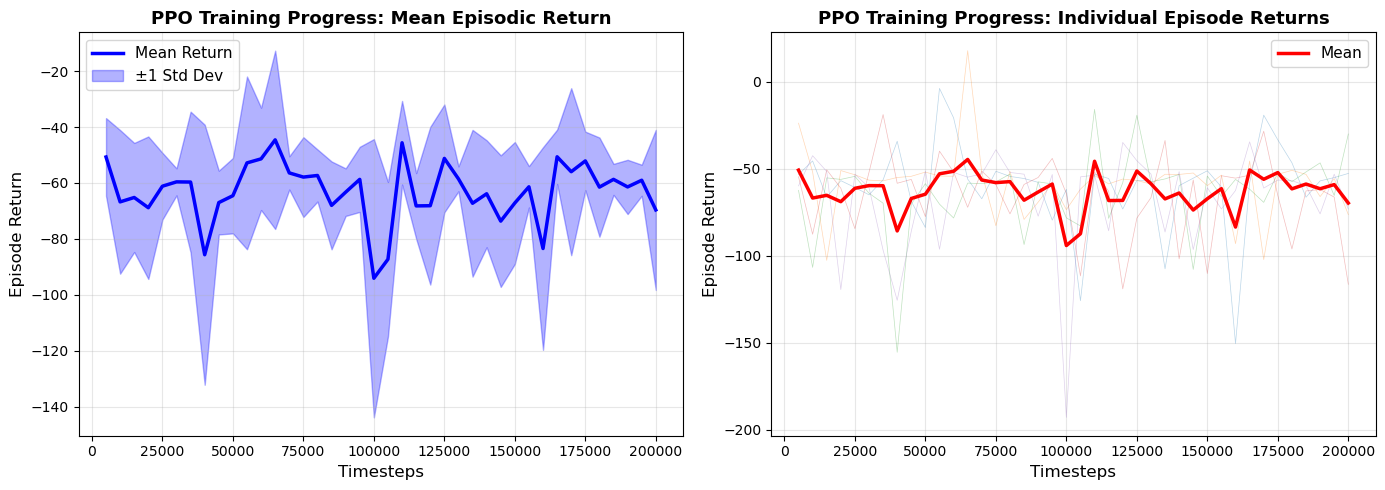


Training Statistics:
Initial mean return: -50.70
Final mean return: -69.64
Improvement: -18.93


In [7]:
# Load and plot evaluation results
# Note: Stable-Baselines3 saves evaluations as .npz (NumPy format), not .json
results_file_npz = os.path.join(dirname, 'evaluations.npz')
results_file_json = os.path.join(dirname, 'evaluations.json')

print(f"Looking for results file (npz): {results_file_npz}")
print(f"File exists (npz): {os.path.exists(results_file_npz)}")

if os.path.exists(results_file_npz):
    # Load from .npz format
    data = np.load(results_file_npz)
    timesteps = data['timesteps']
    results = data['results']
    
    # Calculate mean and std of episode returns
    mean_returns = np.mean(results, axis=1)
    std_returns = np.std(results, axis=1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot mean return with std band
    ax1.plot(timesteps, mean_returns, linewidth=2.5, label='Mean Return', color='blue')
    ax1.fill_between(timesteps, 
                      mean_returns - std_returns, 
                      mean_returns + std_returns, 
                      alpha=0.3, color='blue', label='±1 Std Dev')
    ax1.set_xlabel('Timesteps', fontsize=12)
    ax1.set_ylabel('Episode Return', fontsize=12)
    ax1.set_title('PPO Training Progress: Mean Episodic Return', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=11)
    
    # Plot all individual episode returns
    for i in range(results.shape[1]):
        ax2.plot(timesteps, results[:, i], alpha=0.3, linewidth=0.5)
    ax2.plot(timesteps, mean_returns, linewidth=2.5, label='Mean', color='red')
    ax2.set_xlabel('Timesteps', fontsize=12)
    ax2.set_ylabel('Episode Return', fontsize=12)
    ax2.set_title('PPO Training Progress: Individual Episode Returns', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=11)
    
    plt.tight_layout()
    plt.savefig(os.path.join(dirname, 'learning_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nTraining Statistics:")
    print(f"Initial mean return: {mean_returns[0]:.2f}")
    print(f"Final mean return: {mean_returns[-1]:.2f}")
    print(f"Improvement: {mean_returns[-1] - mean_returns[0]:.2f}")
elif os.path.exists(results_file_json):
    # Fallback to .json format if it exists
    with open(results_file_json, 'r') as f:
        data = json.load(f)
    timesteps = np.array(data['timesteps'])
    results = np.array(data['results'])
    print("Loaded from JSON format")
else:
    print(f"Evaluation results file not found!")
    print(f"Checked locations:")
    print(f"  - {results_file_npz}")
    print(f"  - {results_file_json}")
    print("Make sure training has completed and reached at least one evaluation checkpoint.")


## Example Rollouts

Run the trained policy on several episodes and visualize the trajectories.


In [8]:
# Load the best trained model
best_model_path = os.path.join(dirname, 'best_model', 'best_model.zip')
if os.path.exists(best_model_path):
    trained_model = PPO.load(best_model_path)
else:
    trained_model = model
    print("Using current model (best model not found)")

# Function to run rollouts with the trained policy
def rollout_trained_policy(model, env, episodes=5, seed=42):
    trajectories = []
    returns = []
    successes = 0
    
    # Get the underlying environment if wrapped by Monitor
    unwrapped_env = env.env if hasattr(env, 'env') else env
    max_steps = unwrapped_env.max_num_steps
    
    for episode in range(episodes):
        obs, _ = env.reset(seed=seed + episode)
        trajectory = {
            'obs': [obs.copy()],
            'positions': [obs[:2].copy()],
            'actions': [],
            'rewards': [],
            'success': False,
        }
        
        total_reward = 0.0
        for step in range(max_steps):
            action, _states = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            
            trajectory['obs'].append(obs.copy())
            trajectory['positions'].append(obs[:2].copy())
            trajectory['actions'].append(action.copy())
            trajectory['rewards'].append(reward)
            total_reward += reward
            
            if terminated or truncated:
                if terminated:  # Check if success (collision or out of bounds would truncate differently)
                    # Check if we reached the goal
                    goal_dist = np.linalg.norm(obs[6:8])  # goal relative position
                    if goal_dist < 0.08:  # goal position tolerance
                        trajectory['success'] = True
                        successes += 1
                break
        
        trajectory['total_reward'] = total_reward
        trajectory['positions'] = np.array(trajectory['positions'])
        trajectories.append(trajectory)
        returns.append(total_reward)
        
        print(f"Episode {episode + 1}: Return={total_reward:.2f}, Success={trajectory['success']}")
    
    print(f"\nSuccess rate: {successes}/{episodes} ({100*successes/episodes:.1f}%)")
    return trajectories, returns

# Run rollouts
trajectories, rollout_returns = rollout_trained_policy(trained_model, env, episodes=5, seed=42)


Episode 1: Return=-43.02, Success=False
Episode 2: Return=-51.46, Success=False
Episode 3: Return=-65.17, Success=False
Episode 4: Return=-70.68, Success=False
Episode 5: Return=-55.20, Success=False

Success rate: 0/5 (0.0%)


c:\Users\viato\miniforge3\envs\ae598-arp\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


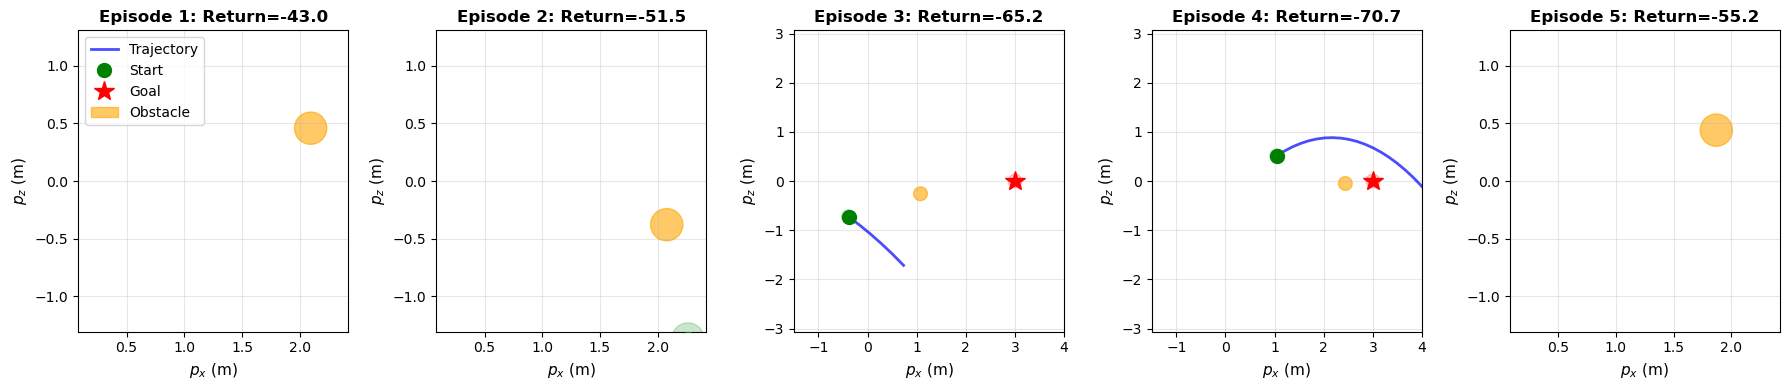


Rollout returns: [np.float64(-43.01803708680098), np.float64(-51.45550158035952), np.float64(-65.16573932977857), np.float64(-70.68081142621475), np.float64(-55.203872111253816)]
Mean return: -57.10
Std return: 9.83


In [9]:
# Visualize trajectories from rollouts
fig, axes = plt.subplots(1, len(trajectories), figsize=(18, 4))
if len(trajectories) == 1:
    axes = [axes]

for idx, traj in enumerate(trajectories):
    ax = axes[idx]
    
    # Plot trajectory
    positions = traj['positions']
    ax.plot(positions[:, 0], positions[:, 1], 'b-', linewidth=2, label='Trajectory', alpha=0.7)
    
    # Plot start and goal
    ax.plot(positions[0, 0], positions[0, 1], 'go', markersize=10, label='Start', zorder=5)
    ax.plot(x_goal[0], x_goal[1], 'r*', markersize=15, label='Goal', zorder=5)
    
    # Plot obstacle (approximate from environment state)
    # The obstacle position is in the observation at indices 8:10 (relative), convert to absolute
    obstacle_rel = np.array(traj['obs'][0][8:10])
    obstacle_pos = np.array(traj['obs'][0][:2]) + obstacle_rel
    circle = plt.Circle(obstacle_pos, r, color='orange', alpha=0.6, label='Obstacle')
    ax.add_patch(circle)
    
    # Add drone radius circles at start and goal
    drone_circle_start = plt.Circle(positions[0], r, color='green', alpha=0.2)
    drone_circle_goal = plt.Circle((x_goal[0], x_goal[1]), r, color='red', alpha=0.2)
    ax.add_patch(drone_circle_start)
    ax.add_patch(drone_circle_goal)
    
    ax.set_xlabel('$p_x$ (m)', fontsize=11)
    ax.set_ylabel('$p_z$ (m)', fontsize=11)
    title = f'Episode {idx + 1}: Return={traj["total_reward"]:.1f}'
    if traj['success']:
        title += ' ✓ SUCCESS'
        ax.set_title(title, fontsize=12, fontweight='bold', color='green')
    else:
        ax.set_title(title, fontsize=12, fontweight='bold')
    
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    if idx == 0:
        ax.legend(fontsize=10, loc='upper left')
    ax.set_xlim([-1.5, 4.0])
    ax.set_ylim([-1.5, 1.5])

plt.tight_layout()
plt.savefig(os.path.join(dirname, 'example_trajectories.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nRollout returns: {rollout_returns}")
print(f"Mean return: {np.mean(rollout_returns):.2f}")
print(f"Std return: {np.std(rollout_returns):.2f}")
